In [1]:
# STEP 17.1 - ML notebook setup

from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Project root
PROJECT_ROOT = Path.cwd().parent

# Final cleaned CICIDS2017 dataset
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "CICIDS2017_final"

# Find processed CSV files
csv_files = sorted(DATA_DIR.glob("*.csv"))

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print("-", file.name)

Project root: c:\Users\DELL\OneDrive\nids\agentic-explainable-nids
Data directory: c:\Users\DELL\OneDrive\nids\agentic-explainable-nids\data\processed\CICIDS2017_final
Number of CSV files: 8
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_final.csv
- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_final.csv
- Friday-WorkingHours-Morning.pcap_ISCX_final.csv
- Monday-WorkingHours.pcap_ISCX_final.csv
- Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX_final.csv
- Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX_final.csv
- Tuesday-WorkingHours.pcap_ISCX_final.csv
- Wednesday-workingHours.pcap_ISCX_final.csv


In [2]:
# STEP 17.2 - Define ML features

CONSTANT_FEATURES = [
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",
    "CWE Flag Count",
    "Fwd URG Flags"
]

# Read column names from the first processed file
sample_columns = pd.read_csv(
    csv_files[0],
    nrows=1
).columns.tolist()

# Remove Label and constant features
FEATURE_COLUMNS = [
    col for col in sample_columns
    if col != "Label" and col not in CONSTANT_FEATURES
]

print("Total original columns:", len(sample_columns))
print("Target column: Label")
print("Constant features excluded:", len(CONSTANT_FEATURES))
print("ML feature count:", len(FEATURE_COLUMNS))

print("\nML Features:")
for i, feature in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i:2}. {feature}")

Total original columns: 79
Target column: Label
Constant features excluded: 10
ML feature count: 68

ML Features:
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Backward Packets
 5. Total Length of Fwd Packets
 6. Total Length of Bwd Packets
 7. Fwd Packet Length Max
 8. Fwd Packet Length Min
 9. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Fwd Header Length
33. Bwd Header Length
34. Fwd Packets/s
35. Bwd Packets/s
36. Min Packet Length
37. Max Packet Length
38. Packet Length Mean
39. Packet Length Std
40. Packet Length Variance
41. FIN Flag Count
42. SYN Flag Count
4

In [4]:
# STEP 17.3 - Create a random ML sample from all files

BASELINE_SAMPLE_SIZE = 400_000
SAMPLES_PER_FILE = 50_000

sample_parts = []

for file in csv_files:
    print(f"Sampling: {file.name}")

    # Read the file in chunks
    file_samples = []

    for chunk in pd.read_csv(
        file,
        usecols=FEATURE_COLUMNS + ["Label"],
        chunksize=100_000
    ):
        # Randomly sample up to 10% of each chunk
        n = min(5_000, len(chunk))

        sampled_chunk = chunk.sample(
            n=n,
            random_state=42
        )

        file_samples.append(sampled_chunk)

    # Combine sampled chunks from this file
    file_sample = pd.concat(
        file_samples,
        ignore_index=True
    )

    # Limit each file to 50,000 rows
    if len(file_sample) > SAMPLES_PER_FILE:
        file_sample = file_sample.sample(
            n=SAMPLES_PER_FILE,
            random_state=42
        )

    sample_parts.append(file_sample)

# Combine all file samples
ml_sample = pd.concat(
    sample_parts,
    ignore_index=True
)

# Shuffle final dataset
ml_sample = ml_sample.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\n" + "=" * 60)
print("RANDOM ML SAMPLE")
print("=" * 60)

print("Rows:", len(ml_sample))
print("Features:", len(FEATURE_COLUMNS))
print("Columns including Label:", ml_sample.shape[1])

print("\nMemory usage:")
print(
    f"{ml_sample.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

print("\nLabel distribution:")
display(
    ml_sample["Label"].value_counts()
)

Sampling: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_final.csv
Sampling: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_final.csv
Sampling: Friday-WorkingHours-Morning.pcap_ISCX_final.csv
Sampling: Monday-WorkingHours.pcap_ISCX_final.csv
Sampling: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX_final.csv
Sampling: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX_final.csv
Sampling: Tuesday-WorkingHours.pcap_ISCX_final.csv
Sampling: Wednesday-workingHours.pcap_ISCX_final.csv

RANDOM ML SAMPLE
Rows: 147464
Features: 68
Columns including Label: 69

Memory usage:
78.52 MB

Label distribution:


Label
BENIGN                      125036
DoS Hulk                      8647
DDoS                          6367
PortScan                      5634
DoS GoldenEye                  503
FTP-Patator                    285
DoS slowloris                  269
DoS Slowhttptest               268
SSH-Patator                    243
Bot                            106
Web Attack � Brute Force        73
Web Attack � XSS                30
Heartbleed                       3
Name: count, dtype: int64

In [8]:
# STEP 17.4 - Get actual labels from the processed dataset

actual_labels = set()

for file in csv_files:
    print(f"Reading labels from: {file.name}")

    for chunk in pd.read_csv(
        file,
        usecols=["Label"],
        chunksize=100_000
    ):
        actual_labels.update(
            chunk["Label"].unique()
        )

actual_labels = sorted(actual_labels)

print("\n" + "=" * 60)
print("ACTUAL DATASET LABELS")
print("=" * 60)

print("Number of classes:", len(actual_labels))

for i, label in enumerate(actual_labels, start=1):
    print(f"{i:2}. {repr(label)}")

Reading labels from: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_final.csv
Reading labels from: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_final.csv
Reading labels from: Friday-WorkingHours-Morning.pcap_ISCX_final.csv
Reading labels from: Monday-WorkingHours.pcap_ISCX_final.csv
Reading labels from: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX_final.csv
Reading labels from: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX_final.csv
Reading labels from: Tuesday-WorkingHours.pcap_ISCX_final.csv
Reading labels from: Wednesday-workingHours.pcap_ISCX_final.csv

ACTUAL DATASET LABELS
Number of classes: 15
 1. 'BENIGN'
 2. 'Bot'
 3. 'DDoS'
 4. 'DoS GoldenEye'
 5. 'DoS Hulk'
 6. 'DoS Slowhttptest'
 7. 'DoS slowloris'
 8. 'FTP-Patator'
 9. 'Heartbleed'
10. 'Infiltration'
11. 'PortScan'
12. 'SSH-Patator'
13. 'Web Attack � Brute Force'
14. 'Web Attack � Sql Injection'
15. 'Web Attack � XSS'


In [9]:
# STEP 17.4.1 - Initialize stratified sampler

TARGET_PER_CLASS = 10_000

class_samples = {
    label: [] for label in actual_labels
}

print("Target samples per class:", TARGET_PER_CLASS)
print("Number of classes:", len(class_samples))

Target samples per class: 10000
Number of classes: 15


In [10]:
# STEP 17.4.2 - Collect samples from all processed files

for file in csv_files:

    print(f"\nProcessing: {file.name}")

    for chunk in pd.read_csv(
        file,
        usecols=FEATURE_COLUMNS + ["Label"],
        chunksize=100_000
    ):

        for label in actual_labels:

            current_count = sum(
                len(part)
                for part in class_samples[label]
            )

            # Already have enough samples
            if current_count >= TARGET_PER_CLASS:
                continue

            label_rows = chunk[
                chunk["Label"] == label
            ]

            remaining = TARGET_PER_CLASS - current_count

            if len(label_rows) > remaining:
                label_rows = label_rows.sample(
                    n=remaining,
                    random_state=42
                )

            if len(label_rows) > 0:
                class_samples[label].append(
                    label_rows
                )

print("\nSampling completed.")


Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_final.csv

Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_final.csv

Processing: Friday-WorkingHours-Morning.pcap_ISCX_final.csv

Processing: Monday-WorkingHours.pcap_ISCX_final.csv

Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX_final.csv

Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX_final.csv

Processing: Tuesday-WorkingHours.pcap_ISCX_final.csv

Processing: Wednesday-workingHours.pcap_ISCX_final.csv

Sampling completed.


In [11]:
# STEP 17.4.3 - Combine all class samples

stratified_parts = []

for label in actual_labels:

    if class_samples[label]:
        label_df = pd.concat(
            class_samples[label],
            ignore_index=True
        )

        stratified_parts.append(label_df)

ml_sample = pd.concat(
    stratified_parts,
    ignore_index=True
)

# Shuffle
ml_sample = ml_sample.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\n" + "=" * 60)
print("STRATIFIED ML SAMPLE")
print("=" * 60)

print("Total rows:", len(ml_sample))
print("Features:", len(FEATURE_COLUMNS))
print("Columns including Label:", ml_sample.shape[1])

print("\nClass distribution:")

stratified_distribution = (
    ml_sample["Label"]
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)

stratified_distribution["Percentage"] = (
    stratified_distribution["Count"]
    / len(ml_sample)
    * 100
)

display(stratified_distribution)


STRATIFIED ML SAMPLE
Total rows: 73901
Features: 68
Columns including Label: 69

Class distribution:


,Label,Count,Percentage
0,PortScan,10000,13.531617
1,BENIGN,10000,13.531617
2,DoS Hulk,10000,13.531617
3,DDoS,10000,13.531617
4,DoS GoldenEye,10000,13.531617
5,FTP-Patator,5931,8.025602
6,DoS slowloris,5385,7.286776
7,DoS Slowhttptest,5228,7.074329
8,SSH-Patator,3219,4.355827
9,Bot,1948,2.635959


In [12]:
# STEP 17.5 - Separate features and target

X = ml_sample[FEATURE_COLUMNS]
y = ml_sample["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature data types:")
print(X.dtypes.value_counts())

print("\nNumber of classes:", y.nunique())

X shape: (73901, 68)
y shape: (73901,)

Feature data types:
int64      44
float64    24
Name: count, dtype: int64

Number of classes: 15


In [13]:
# STEP 17.6 - Stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Testing labels:", y_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts())

print("\nTesting class distribution:")
display(y_test.value_counts())

TRAIN-TEST SPLIT
Training features: (59120, 68)
Testing features: (14781, 68)

Training labels: (59120,)
Testing labels: (14781,)

Training class distribution:


Label
DoS GoldenEye                 8000
PortScan                      8000
DDoS                          8000
DoS Hulk                      8000
BENIGN                        8000
FTP-Patator                   4745
DoS slowloris                 4308
DoS Slowhttptest              4182
SSH-Patator                   2575
Bot                           1558
Web Attack � Brute Force      1176
Web Attack � XSS               521
Infiltration                    29
Web Attack � Sql Injection      17
Heartbleed                       9
Name: count, dtype: int64


Testing class distribution:


Label
BENIGN                        2000
DoS GoldenEye                 2000
DDoS                          2000
PortScan                      2000
DoS Hulk                      2000
FTP-Patator                   1186
DoS slowloris                 1077
DoS Slowhttptest              1046
SSH-Patator                    644
Bot                            390
Web Attack � Brute Force       294
Web Attack � XSS               131
Infiltration                     7
Web Attack � Sql Injection       4
Heartbleed                       2
Name: count, dtype: int64

In [14]:
# STEP 17.7 - Train Random Forest baseline

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("\nRandom Forest training completed.")

Training Random Forest...

Random Forest training completed.


In [15]:
# STEP 17.8 - Random Forest predictions

print("Generating predictions...")

y_pred = rf_model.predict(X_test)

print("Predictions completed.")

print("\nNumber of predictions:", len(y_pred))
print("Number of actual labels:", len(y_test))

Generating predictions...
Predictions completed.

Number of predictions: 14781
Number of actual labels: 14781


In [16]:
# STEP 17.9 - Evaluate Random Forest baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate overall metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("RANDOM FOREST BASELINE RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

RANDOM FOREST BASELINE RESULTS
Accuracy : 0.9864
Precision: 0.9862
Recall   : 0.9864
F1-Score : 0.9863

CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99      2000
                       Bot       0.97      0.99      0.98       390
                      DDoS       1.00      1.00      1.00      2000
             DoS GoldenEye       1.00      1.00      1.00      2000
                  DoS Hulk       1.00      1.00      1.00      2000
          DoS Slowhttptest       1.00      0.99      1.00      1046
             DoS slowloris       0.99      1.00      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       1.00      1.00      1.00      2000
               SSH-Patator       1.00      1.00      1.00

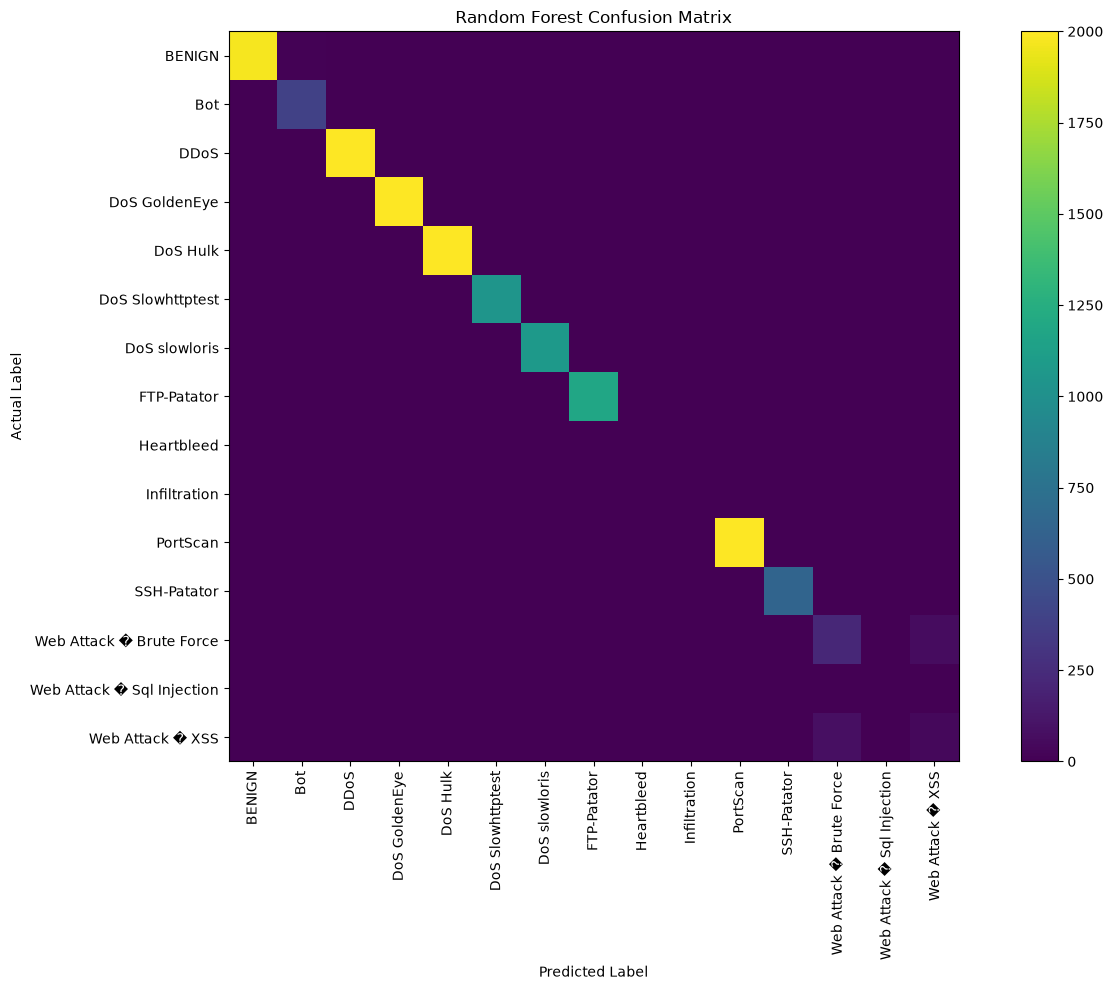

In [17]:
# STEP 17.10 - Confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Get labels in a fixed order
class_names = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

plt.figure(figsize=(14, 10))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()

plt.tight_layout()
plt.show()

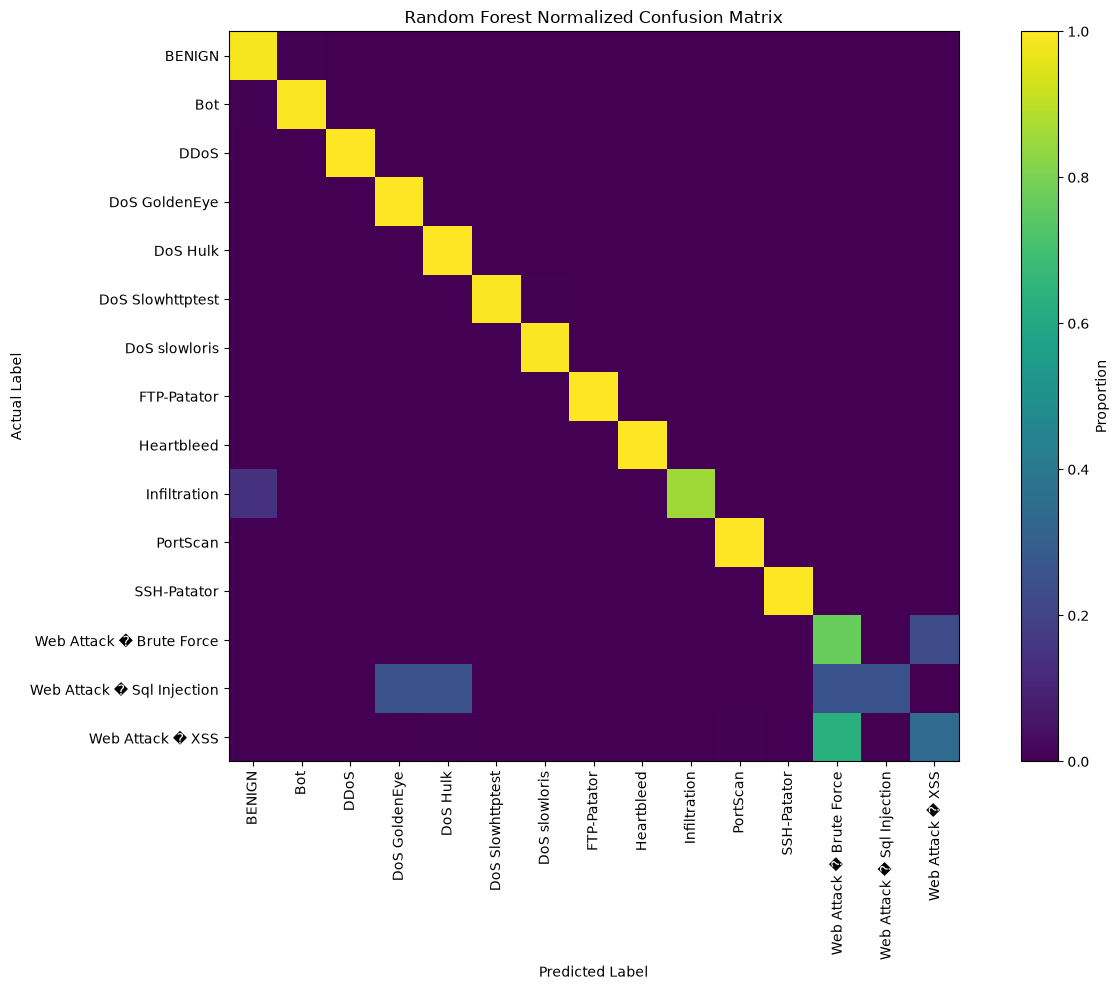

In [18]:
# STEP 17.11 - Normalized confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

class_names = sorted(y_test.unique())

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

# Normalize each row
cm_normalized = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

plt.figure(figsize=(14, 10))

plt.imshow(
    cm_normalized,
    vmin=0,
    vmax=1
)

plt.title("Random Forest Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar(label="Proportion")

plt.tight_layout()
plt.show()

In [19]:
# STEP 17.12 - Macro evaluation metrics

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("MACRO-AVERAGED METRICS")
print("=" * 60)

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro F1-Score : {macro_f1:.4f}")

MACRO-AVERAGED METRICS
Macro Precision: 0.9038
Macro Recall   : 0.8797
Macro F1-Score : 0.8885


In [20]:
# STEP 17.13 - False Positive Rate

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

class_names = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

fpr_results = []

for i, class_name in enumerate(class_names):

    # True Positives
    TP = cm[i, i]

    # False Positives
    FP = cm[:, i].sum() - TP

    # False Negatives
    FN = cm[i, :].sum() - TP

    # True Negatives
    TN = cm.sum() - (TP + FP + FN)

    # False Positive Rate
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    fpr_results.append({
        "Class": class_name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "FPR": FPR
    })

fpr_df = pd.DataFrame(fpr_results)

print("=" * 70)
print("FALSE POSITIVE RATE BY CLASS")
print("=" * 70)

display(fpr_df)

FALSE POSITIVE RATE BY CLASS


,Class,TP,FP,FN,TN,FPR
0,BENIGN,1976,10,24,12771,0.000782
1,Bot,388,14,2,14377,0.000973
2,DDoS,2000,0,0,12781,0.000000
3,DoS GoldenEye,1998,5,2,12776,0.000391
4,DoS Hulk,1997,2,3,12779,0.000156
5,DoS Slowhttptest,1040,2,6,13733,0.000146
6,DoS slowloris,1072,6,5,13698,0.000438
7,FTP-Patator,1186,0,0,13595,0.000000
8,Heartbleed,2,0,0,14779,0.000000
9,Infiltration,6,0,1,14774,0.000000


In [21]:
# STEP 17.14 - Store Random Forest baseline results

rf_baseline_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1": f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Benign False Positive Rate": 24 / 2000
}

rf_baseline_df = pd.DataFrame([rf_baseline_results])

display(rf_baseline_df)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,Benign False Positive Rate
0,Random Forest,0.986401,0.986234,0.986401,0.986277,0.903757,0.879662,0.888458,0.012
